# NASA 锂离子电池退化分析与 RUL 预测：从基准模型到特征工程

**Date**: 2026-03-11  
**Dataset**: NASA Ames Prognostics Center of Excellence (PCoE) Battery Dataset  

---

##  摘要 (Abstract)
本笔记旨在系统性地处理并分析 NASA PCoE 提供的多工况锂离子电池老化数据集。研究的核心目标是提取能够表征电池健康状态 (State of Health, $SOH$) 的多维物理特征，并为后续的**剩余使用寿命 (Remaining Useful Life, RUL)** 预测构建高强度的机器学习与深度学习管道。

本阶段包含以下核心工作：
1. **全局实验配置**：确立可复现的随机种子与可视化基准。
2. **基准模型建立 (Baseline)**：利用一元线性回归验证单纯依靠“循环次数”进行预测的局限性。
3. **多维特征工程 (Feature Engineering)**：针对嵌套字典结构的 `.mat` 文件，设计具备强鲁棒性（捕获软件崩溃、NaN 缺失值等脏数据）的特征提取脚本。
4. **数据持久化**：将非结构化时序数据转化为标准的二维特征矩阵 (`.csv`)。

---

In [ ]:
# ==========================================
# 1. 环境准备与全局设置 (Setup & Configuration)
# ==========================================

import os
import warnings
import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 忽略非致命警告，保持 Notebook 输出清爽
warnings.filterwarnings('ignore')

# 保证后续所有涉及随机性的算法（如数据打乱、网络初始化）可复现
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 1. 解决中文字体显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 用户首选
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # 如果你是 Mac 用户，请把这句取消注释并删掉上面那句
plt.rcParams['axes.unicode_minus'] = False 

# 2. 提升图表分辨率 
%config InlineBackend.figure_format = 'retina'

# 3. 统一图表风格与字号
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'grid.alpha': 0.5
})


## 2. 物理机理回顾与线性基准 (Baseline Establishment)

在引入复杂的深度神经网络（如 LSTM/Transformer）提取动态工况特征之前，建立一个极简的基准模型 (Baseline Model) 是验证数据可用性并防范“过拟合错觉”的必要步骤。

我们将以室温标准放电工况下的 **B0005** 电池为例，尝试构建最基础的一元线性回归方程：
$$C_N = w \cdot N + b$$
其中 $C_N$ 为第 $N$ 次循环的预测容量。我们将借此图直观论证**简单线性模型无法捕捉电池老化后期的加速非线性衰减以及局部的自恢复效应 (Capacity Regeneration)**，从而为后续的多维特征工程提供坚实的动机。

### B0005线性回归实验

====== B0005 线性基准模型评估 ======
拟合方程: Capacity = -0.00387 * Cycle + 1.89923
决定系数 (R²): 0.9756
均方误差 (MSE): 0.000878


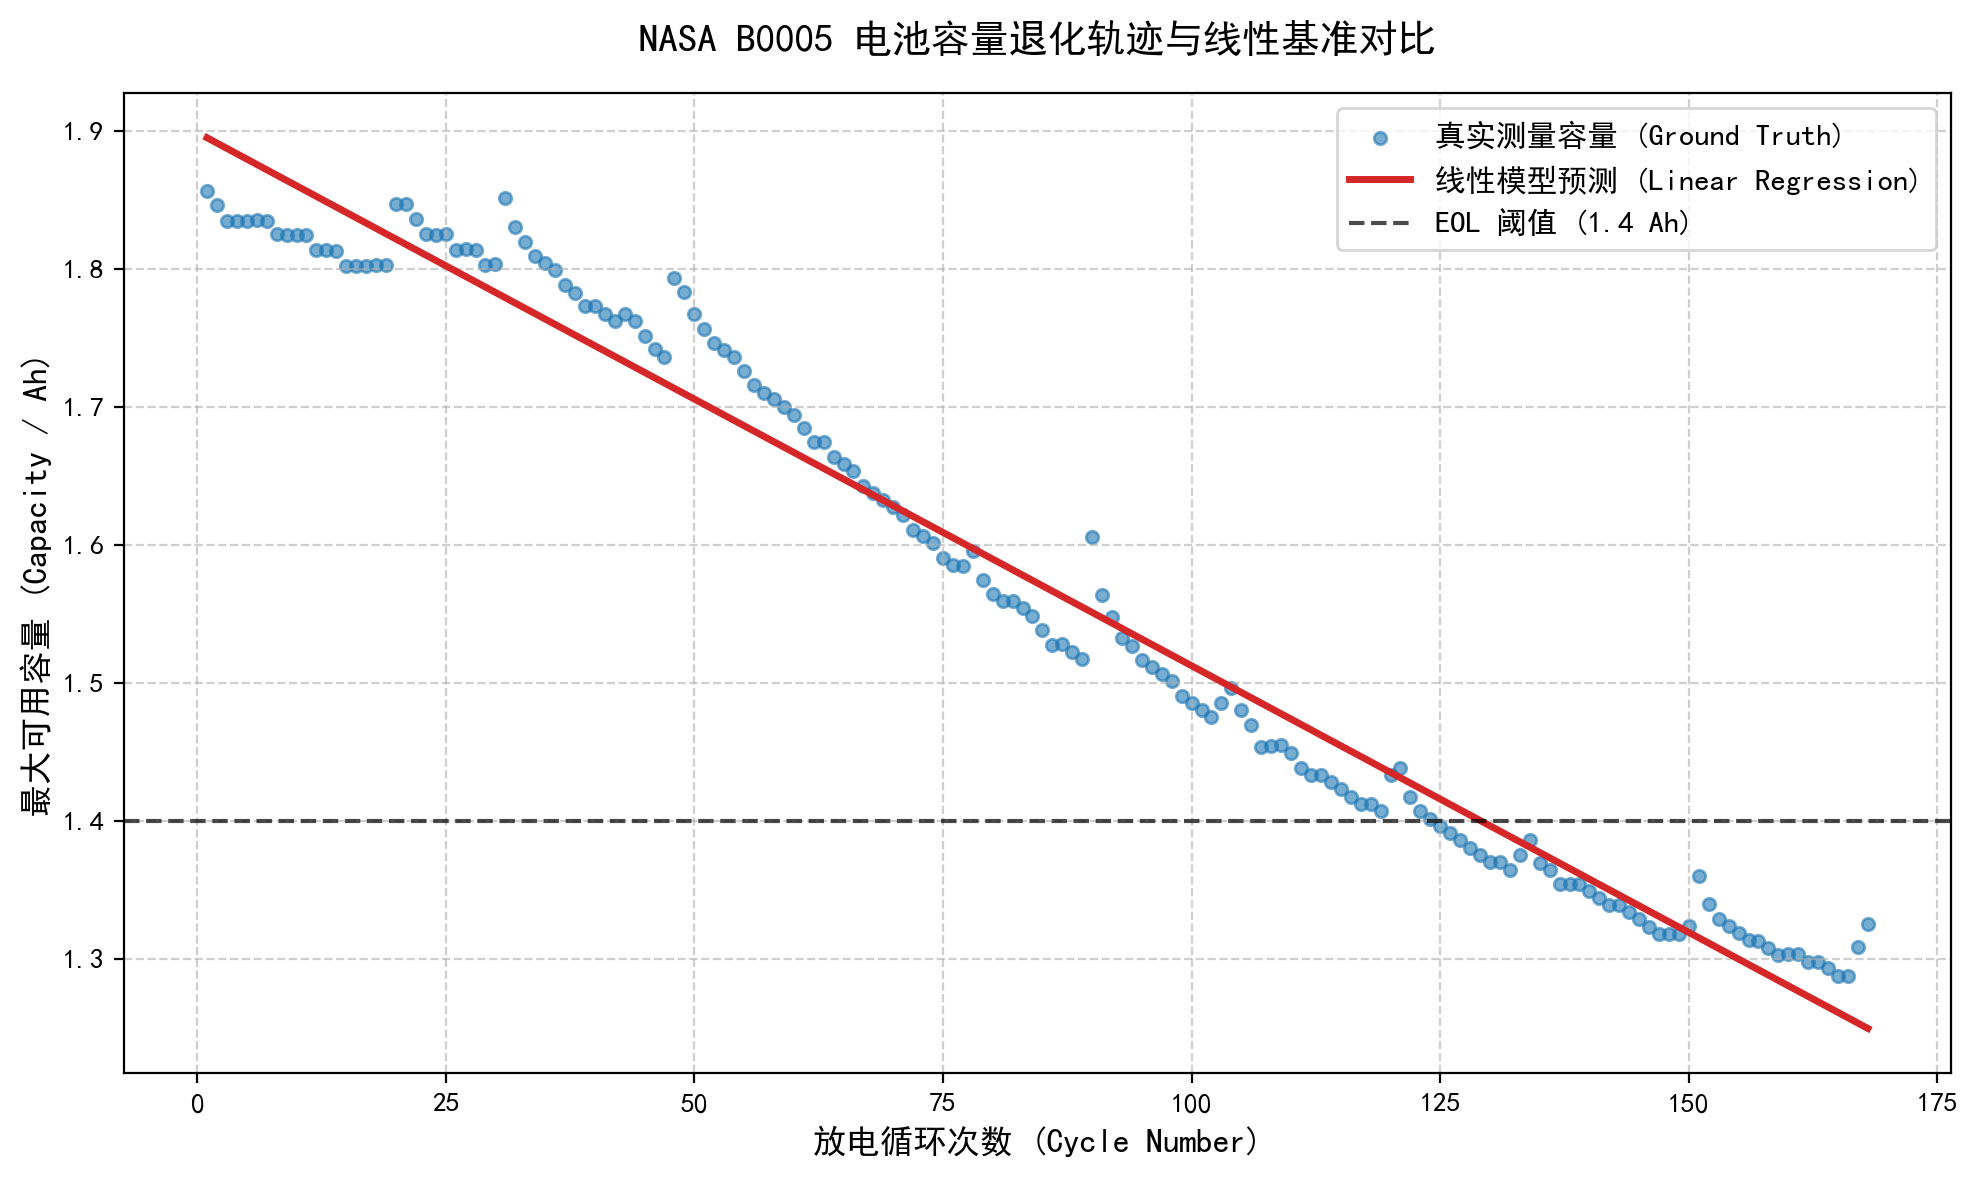

In [ ]:
# ==========================================
# 2. 线性回归基准测试 (Linear Regression Baseline)
# ==========================================

# 为了保证代码块的独立性，我们在此处定义一个轻量级的提取函数
def get_battery_capacity(file_path):
    mat_data = scipy.io.loadmat(file_path)
    battery_name = [k for k in mat_data.keys() if not k.startswith('__')][0]
    cycles = mat_data[battery_name][0, 0]['cycle'][0]
    
    capacities = []
    for i in range(len(cycles)):
        if cycles[i]['type'][0] == 'discharge':
            try:
                cap = cycles[i]['data'][0, 0]['Capacity'][0, 0]
                capacities.append(cap)
            except IndexError:
                # 遇到脏数据跳过或填入 NaN
                capacities.append(np.nan)
    return battery_name, capacities

# 1. 加载基准对照组电池 B0005
# 请确保这里的相对路径与你电脑上的文件夹结构一致
file_path_b0005 = r'../data/raw/1. BatteryAgingARC-FY08Q4/B0005.mat'

if os.path.exists(file_path_b0005):
    batt_name, raw_caps = get_battery_capacity(file_path_b0005)
    
    # 2. 数据清洗：剔除可能存在的 NaN 值，以免线性回归报错
    clean_data = [(idx + 1, cap) for idx, cap in enumerate(raw_caps) if not np.isnan(cap)]
    X = np.array([item[0] for item in clean_data]).reshape(-1, 1) # 特征：循环次数 (二维矩阵)
    y = np.array([item[1] for item in clean_data])                # 标签：真实容量
    
    # 3. 模型实例化与训练
    lr_model = LinearRegression()
    lr_model.fit(X, y)
    
    # 4. 模型预测与评估
    y_pred = lr_model.predict(X)
    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    
    print(f"====== {batt_name} 线性基准模型评估 ======")
    print(f"拟合方程: Capacity = {lr_model.coef_[0]:.5f} * Cycle + {lr_model.intercept_:.5f}")
    print(f"决定系数 (R²): {r2:.4f}")
    print(f"均方误差 (MSE): {mse:.6f}")
    
    # 5. 学术级可视化
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color='#1f77b4', alpha=0.6, s=20, label='真实测量容量 (Ground Truth)')
    plt.plot(X, y_pred, color='#d62728', linewidth=2.5, label='线性模型预测 (Linear Regression)')
    
    # 添加 EOL (寿命终止) 阈值线
    plt.axhline(y=1.4, color='black', linestyle='--', alpha=0.7, label='EOL 阈值 (1.4 Ah)')
    
    plt.title(f'NASA {batt_name} 电池容量退化轨迹与线性基准对比', pad=15)
    plt.xlabel('放电循环次数 (Cycle Number)')
    plt.ylabel('最大可用容量 (Capacity / Ah)')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
else:
    print(f"❌ 找不到文件：{file_path_b0005}，请检查路径。")

通过建立一元线性回归模型，我们得到了极高的拟合优度 ($R^2 = 0.9756$)，回归方程为 $Capacity = -0.00387 \cdot Cycle + 1.89923$。这表明在**单一恒定工况 (24°C, 2A)** 下，电池的宏观退化表现出极强的线性衰减特征（单次循环约衰减 3.87 mAh）。

### 其余组对比线性回归

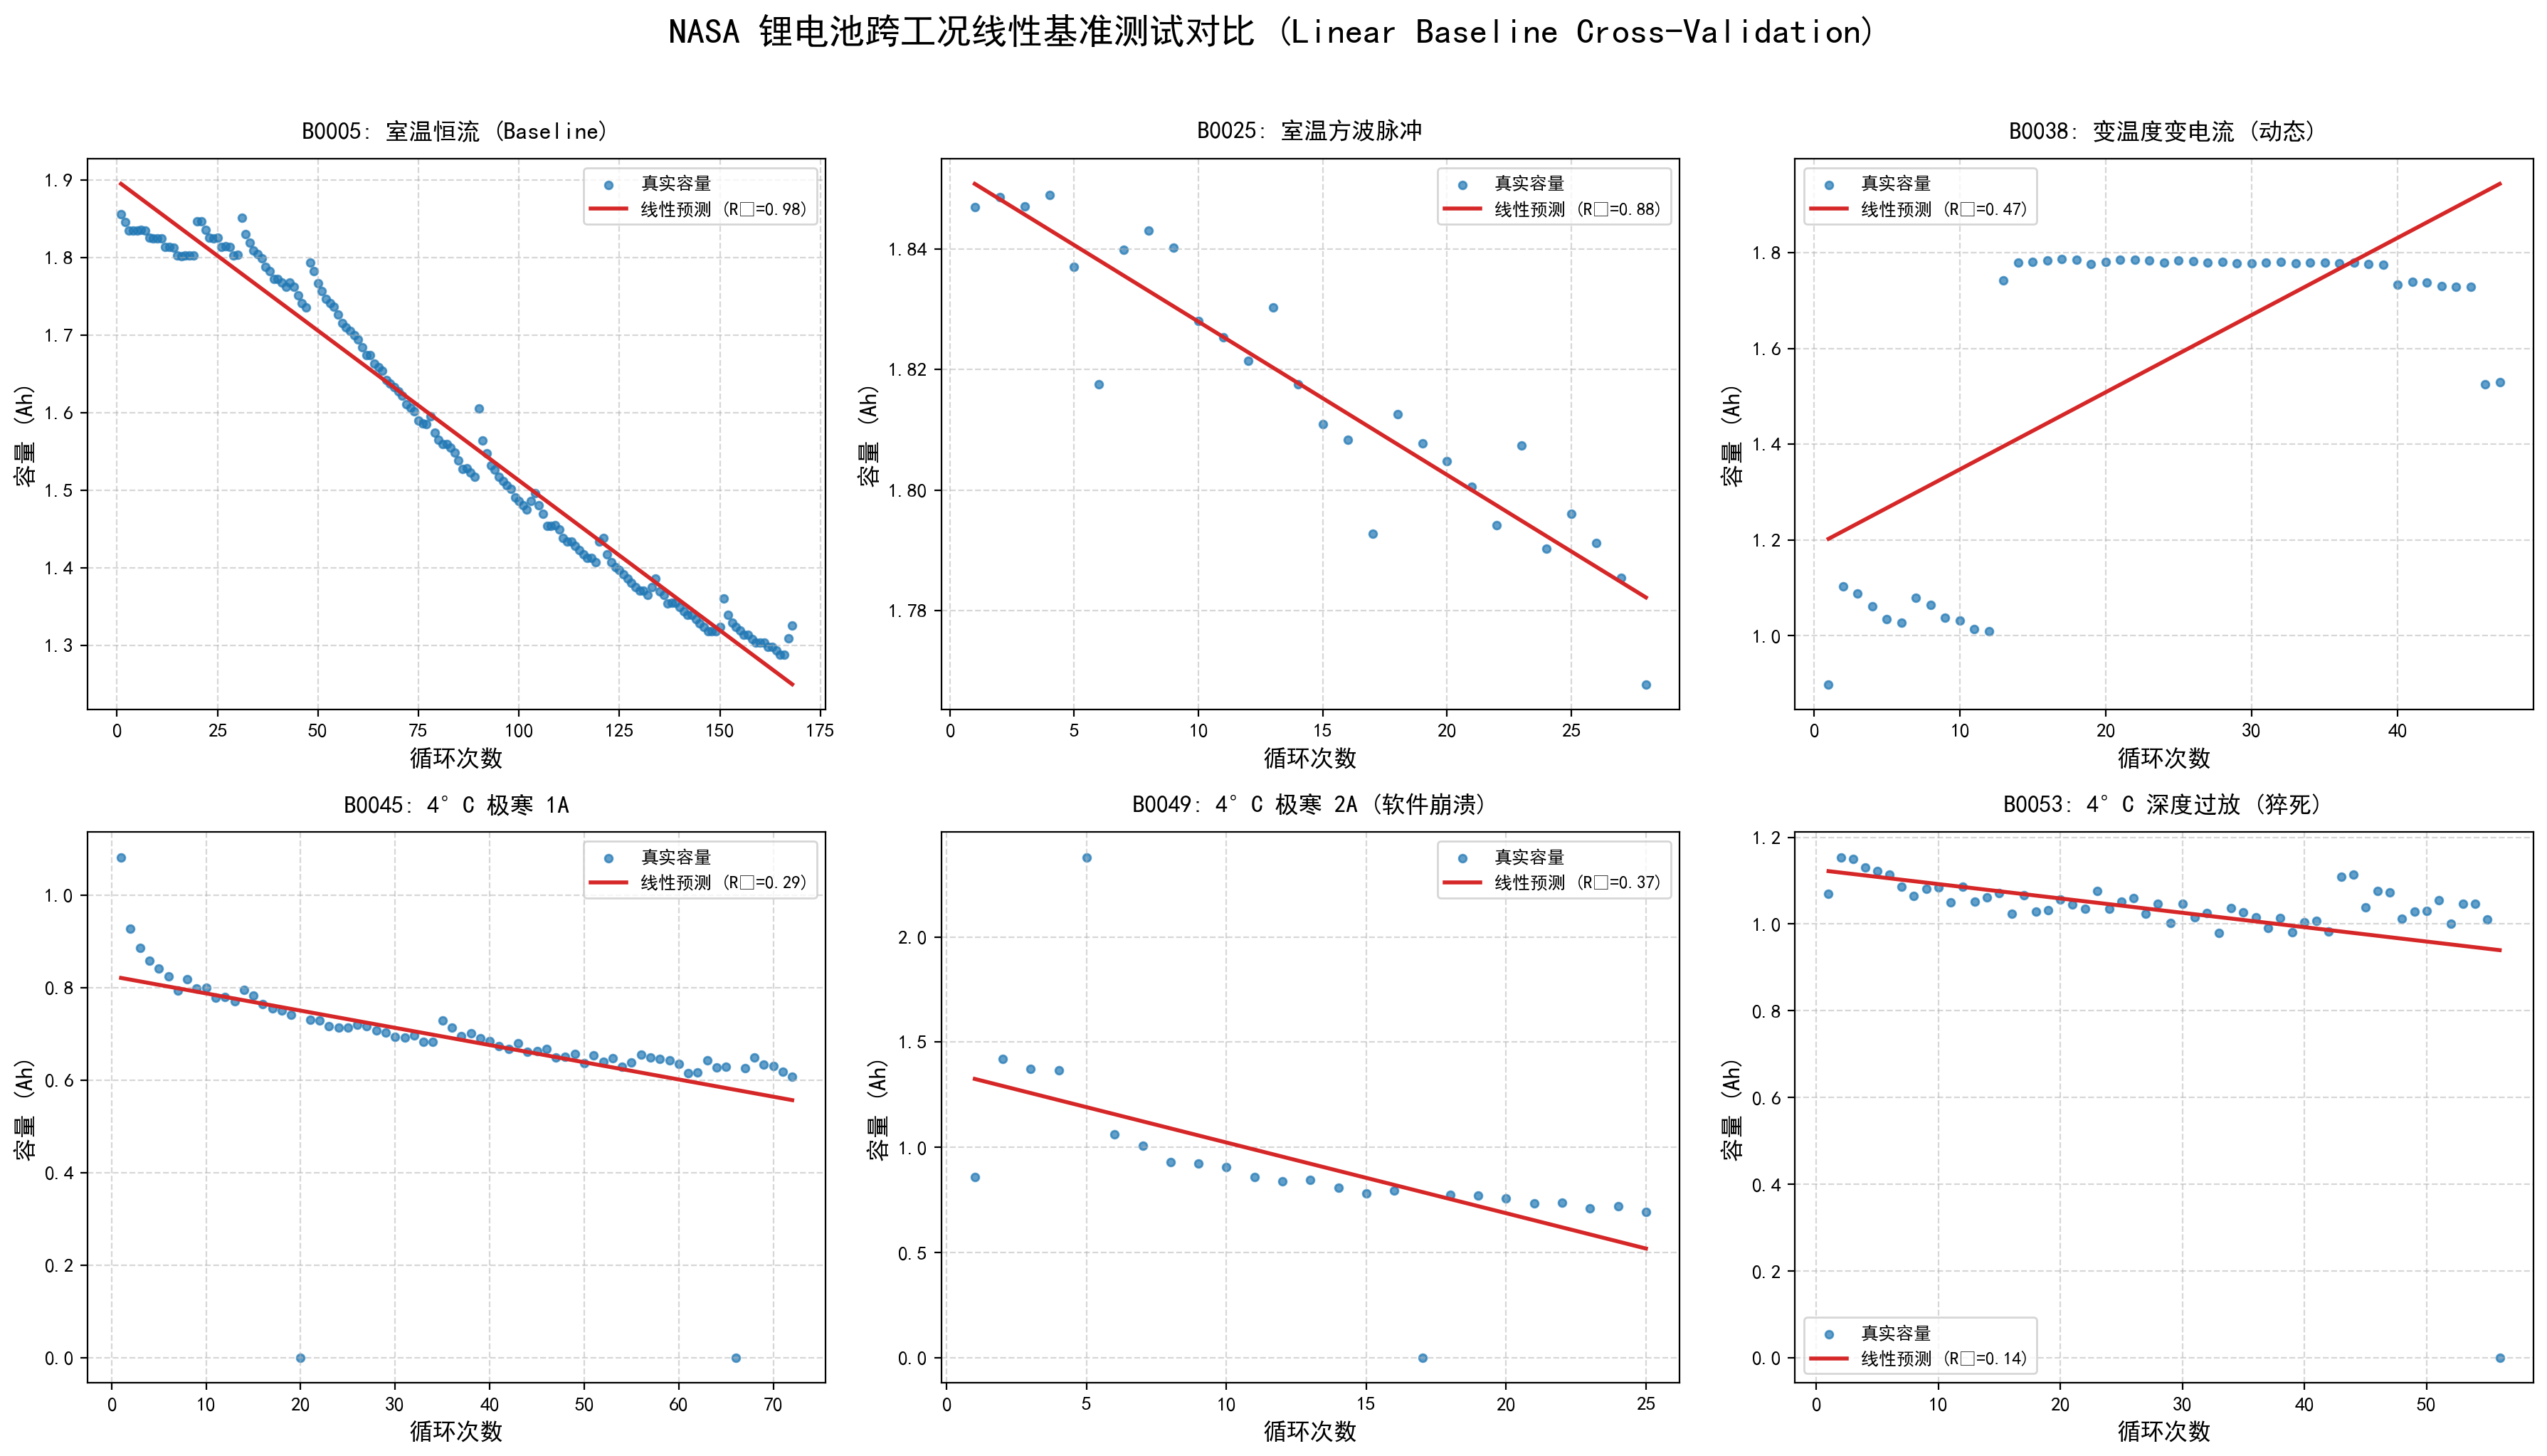

In [ ]:
import os
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ==========================================
# 3. 跨工况线性基准对比 (Cross-Condition Baseline)
# ==========================================


def get_capacity_robust(file_path):
    mat_data = scipy.io.loadmat(file_path)
    battery_name = [k for k in mat_data.keys() if not k.startswith('__')][0]
    cycles = mat_data[battery_name][0, 0]['cycle'][0]
    
    caps = []
    for i in range(len(cycles)):
        if cycles[i]['type'][0] == 'discharge':
            try:
                caps.append(cycles[i]['data'][0, 0]['Capacity'][0, 0])
            except IndexError:
                caps.append(np.nan)
    return battery_name, caps

# 精心挑选的 6 个代表性电池的路径与标签

battery_configs = [
    (r'../data/raw/1. BatteryAgingARC-FY08Q4/B0005.mat', '室温恒流 (Baseline)'),
    (r'../data/raw/2. BatteryAgingARC_25_26_27_28_P1/B0025.mat', '室温方波脉冲'),
    (r'../data/raw/3. BatteryAgingARC_25-44/B0038.mat', '变温度变电流 (动态)'),
    (r'../data/raw/4. BatteryAgingARC_45_46_47_48/B0045.mat', '4°C 极寒 1A'),
    (r'../data/raw/5. BatteryAgingARC_49_50_51_52/B0049.mat', '4°C 极寒 2A (软件崩溃)'),
    (r'../data/raw/6. BatteryAgingARC_53_54_55_56/B0053.mat', '4°C 深度过放 (猝死)')
]

# 按导师建议修改：创建 3 行 2 列，以保证每个子图在横竖方向上有充足的显示空间
# 画布高度适当增加以适配 3 行
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten() # 展平轴数组，方便循环遍历

for idx, (path, condition_desc) in enumerate(battery_configs):
    ax = axes[idx]
    
    if os.path.exists(path):
        batt_name, raw_caps = get_capacity_robust(path)
        
        # 数据清洗：剔除 NaN 缺失值
        clean_data = [(i + 1, cap) for i, cap in enumerate(raw_caps) if not np.isnan(cap)]
        
        if len(clean_data) > 0:
            X = np.array([item[0] for item in clean_data]).reshape(-1, 1)
            y = np.array([item[1] for item in clean_data])
            
            # 训练线性回归模型
            lr = LinearRegression()
            lr.fit(X, y)
            y_pred = lr.predict(X)
            r2 = r2_score(y, y_pred)
            
            # 绘图
            ax.scatter(X, y, color='#1f77b4', s=20, alpha=0.7, label='真实容量')
            ax.plot(X, y_pred, color='#d62728', linewidth=2.5, label=f'线性预测 (R²={r2:.2f})')
            # 适当增大子图的标题字号，显示更清晰
            ax.set_title(f'{batt_name}: {condition_desc}', fontsize=14, pad=10, fontweight='bold')
            ax.set_xlabel('循环次数', fontsize=12)
            ax.set_ylabel('容量 (Ah)', fontsize=12)
            ax.legend(loc='best', fontsize=10)
            ax.grid(True, linestyle='--', alpha=0.6)
        else:
            ax.set_title(f'{path.split("/")[-1]} 数据全空', color='red')
    else:
        ax.set_title(f'找不到文件: {path.split("/")[-1]}', color='red')
        ax.axis('off')

plt.suptitle('NASA 锂电池跨工况线性基准测试对比 (Linear Baseline Cross-Validation)', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 特征工程

结合电池老化的物理和电化学机理，我们使用以下三个特征
- 放电时长 (Discharge Time)：随着电池老化，内阻增大，电池触碰截止电压的时间会越来越短。这是与容量高度强相关的黄金特征。
- 放电最高温度 (Max Temperature)：老化严重的电池，其内部极化和欧姆发热效应会显著增强。在相同的放电电流下，老电池的峰值温度往往更高：$Q = I^2 \cdot R_{int} \cdot t$。
- 放电初始电压 (Initial Voltage)：反映了电池在静置后、刚刚加上负载瞬间的极化压降，直接关联电池的欧姆内阻状态。

In [ ]:
# ==========================================
# 4. 多维特征工程 (Feature Engineering Pipeline)
# ==========================================
import os
import scipy.io
import numpy as np
import pandas as pd

def extract_health_indicators(file_path):
    """
    核心特征提取函数：从 .mat 文件中提取多维健康因子 (HIs)
    返回: battery_name (str), df_features (Pandas DataFrame)
    """
    mat_data = scipy.io.loadmat(file_path)
    battery_name = [k for k in mat_data.keys() if not k.startswith('__')][0]
    cycles = mat_data[battery_name][0, 0]['cycle'][0]
    
    feature_list = []
    cycle_count = 0 # 真实的循环计数器
    
    for i in range(len(cycles)):
        # 我们目前主要从 'discharge' (放电) 阶段提取特征和标签
        if cycles[i]['type'][0] == 'discharge':
            cycle_count += 1
            try:
                data_struct = cycles[i]['data'][0, 0]
                
                # 1. 提取预测目标 (Label Y)
                capacity = data_struct['Capacity'][0, 0]
                
                # 2. 提取物理序列数据 (Arrays)
                voltages = data_struct['Voltage_measured'][0]
                temps = data_struct['Temperature_measured'][0]
                times = data_struct['Time'][0]
                
                # 3. 计算健康因子 (Features X)
                # 特征 1: 放电持续时间 (最后一个时间点)
                discharge_time = times[-1] 
                # 特征 2: 放电过程中的最高温度
                max_temp = np.max(temps)
                # 特征 3: 放电初始电压 (刚加负载时的电压)
                init_voltage = voltages[0]
                
                # 将该次循环的特征打包为字典
                feature_list.append({
                    'Cycle': cycle_count,
                    'Capacity': capacity,              # Target (Y)
                    'Discharge_Time': discharge_time,  # Feature 1
                    'Max_Temp': max_temp,              # Feature 2
                    'Init_Voltage': init_voltage       # Feature 3
                })
                
            except (IndexError, ValueError) as e:
                # 异常捕获：如果是软件崩溃导致的空数据，记录 NaN
                feature_list.append({
                    'Cycle': cycle_count,
                    'Capacity': np.nan,
                    'Discharge_Time': np.nan,
                    'Max_Temp': np.nan,
                    'Init_Voltage': np.nan
                })
                print(f"⚠️ 警告: {battery_name} 在第 {cycle_count} 次循环存在数据缺失。")
                
    # 将字典列表转换为结构化的 Pandas DataFrame
    df = pd.DataFrame(feature_list)
    return battery_name, df

# ----------------- 试运行：以 B0005 为例 -----------------
# 请确保路径正确
file_path_b0005 = r'../data/raw/1. BatteryAgingARC-FY08Q4/B0005.mat'

if os.path.exists(file_path_b0005):
    batt_name, df_b0005 = extract_health_indicators(file_path_b0005)
    
    print(f" {batt_name} 特征提取成功！数据表形状: {df_b0005.shape}")
    print("-" * 50)
    # 打印前 5 行看看我们的劳动成果
    display(df_b0005.head()) 
else:
    print(f"❌ 找不到文件：{file_path_b0005}")

 B0005 特征提取成功！数据表形状: (168, 5)
--------------------------------------------------


,Cycle,Capacity,Discharge_Time,Max_Temp,Init_Voltage
0,1,1.856487,3690.234,38.982181,4.191492
1,2,1.846327,3672.344,39.033398,4.189773
2,3,1.835349,3651.641,38.818797,4.188187
3,4,1.835263,3631.563,38.762305,4.188461
4,5,1.834646,3629.172,38.665393,4.188299


### 5. 特征有效性验证：皮尔逊相关性分析 (Pearson Correlation Analysis)

在将提取的间接健康因子 (Indirect Health Indicators, IHIs) 输入深度学习模型之前，我们必须进行定量的有效性验证。
我们将采用**皮尔逊相关系数 (Pearson Correlation Coefficient, $r$)** 来衡量各个物理特征与电池实际剩余容量 (Capacity) 之间的线性相关程度。

皮尔逊相关系数的数学定义为：
$$r_{xy} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$

* **评判标准**：$r$ 的取值范围为 $[-1, 1]$。绝对值 $|r|$ 越接近 1，说明该特征与容量的共线性越强，对模型预测剩余使用寿命 (RUL) 的贡献越大。
* **物理预期**：随着老化，可用容量下降。我们预期**放电时间 (Discharge_Time)** 会与容量呈高度**正相关** ($r \to 1$)；而**最高温度 (Max_Temp)** 由于极化内阻产热增加，预期与容量呈高度**负相关** ($r \to -1$)。

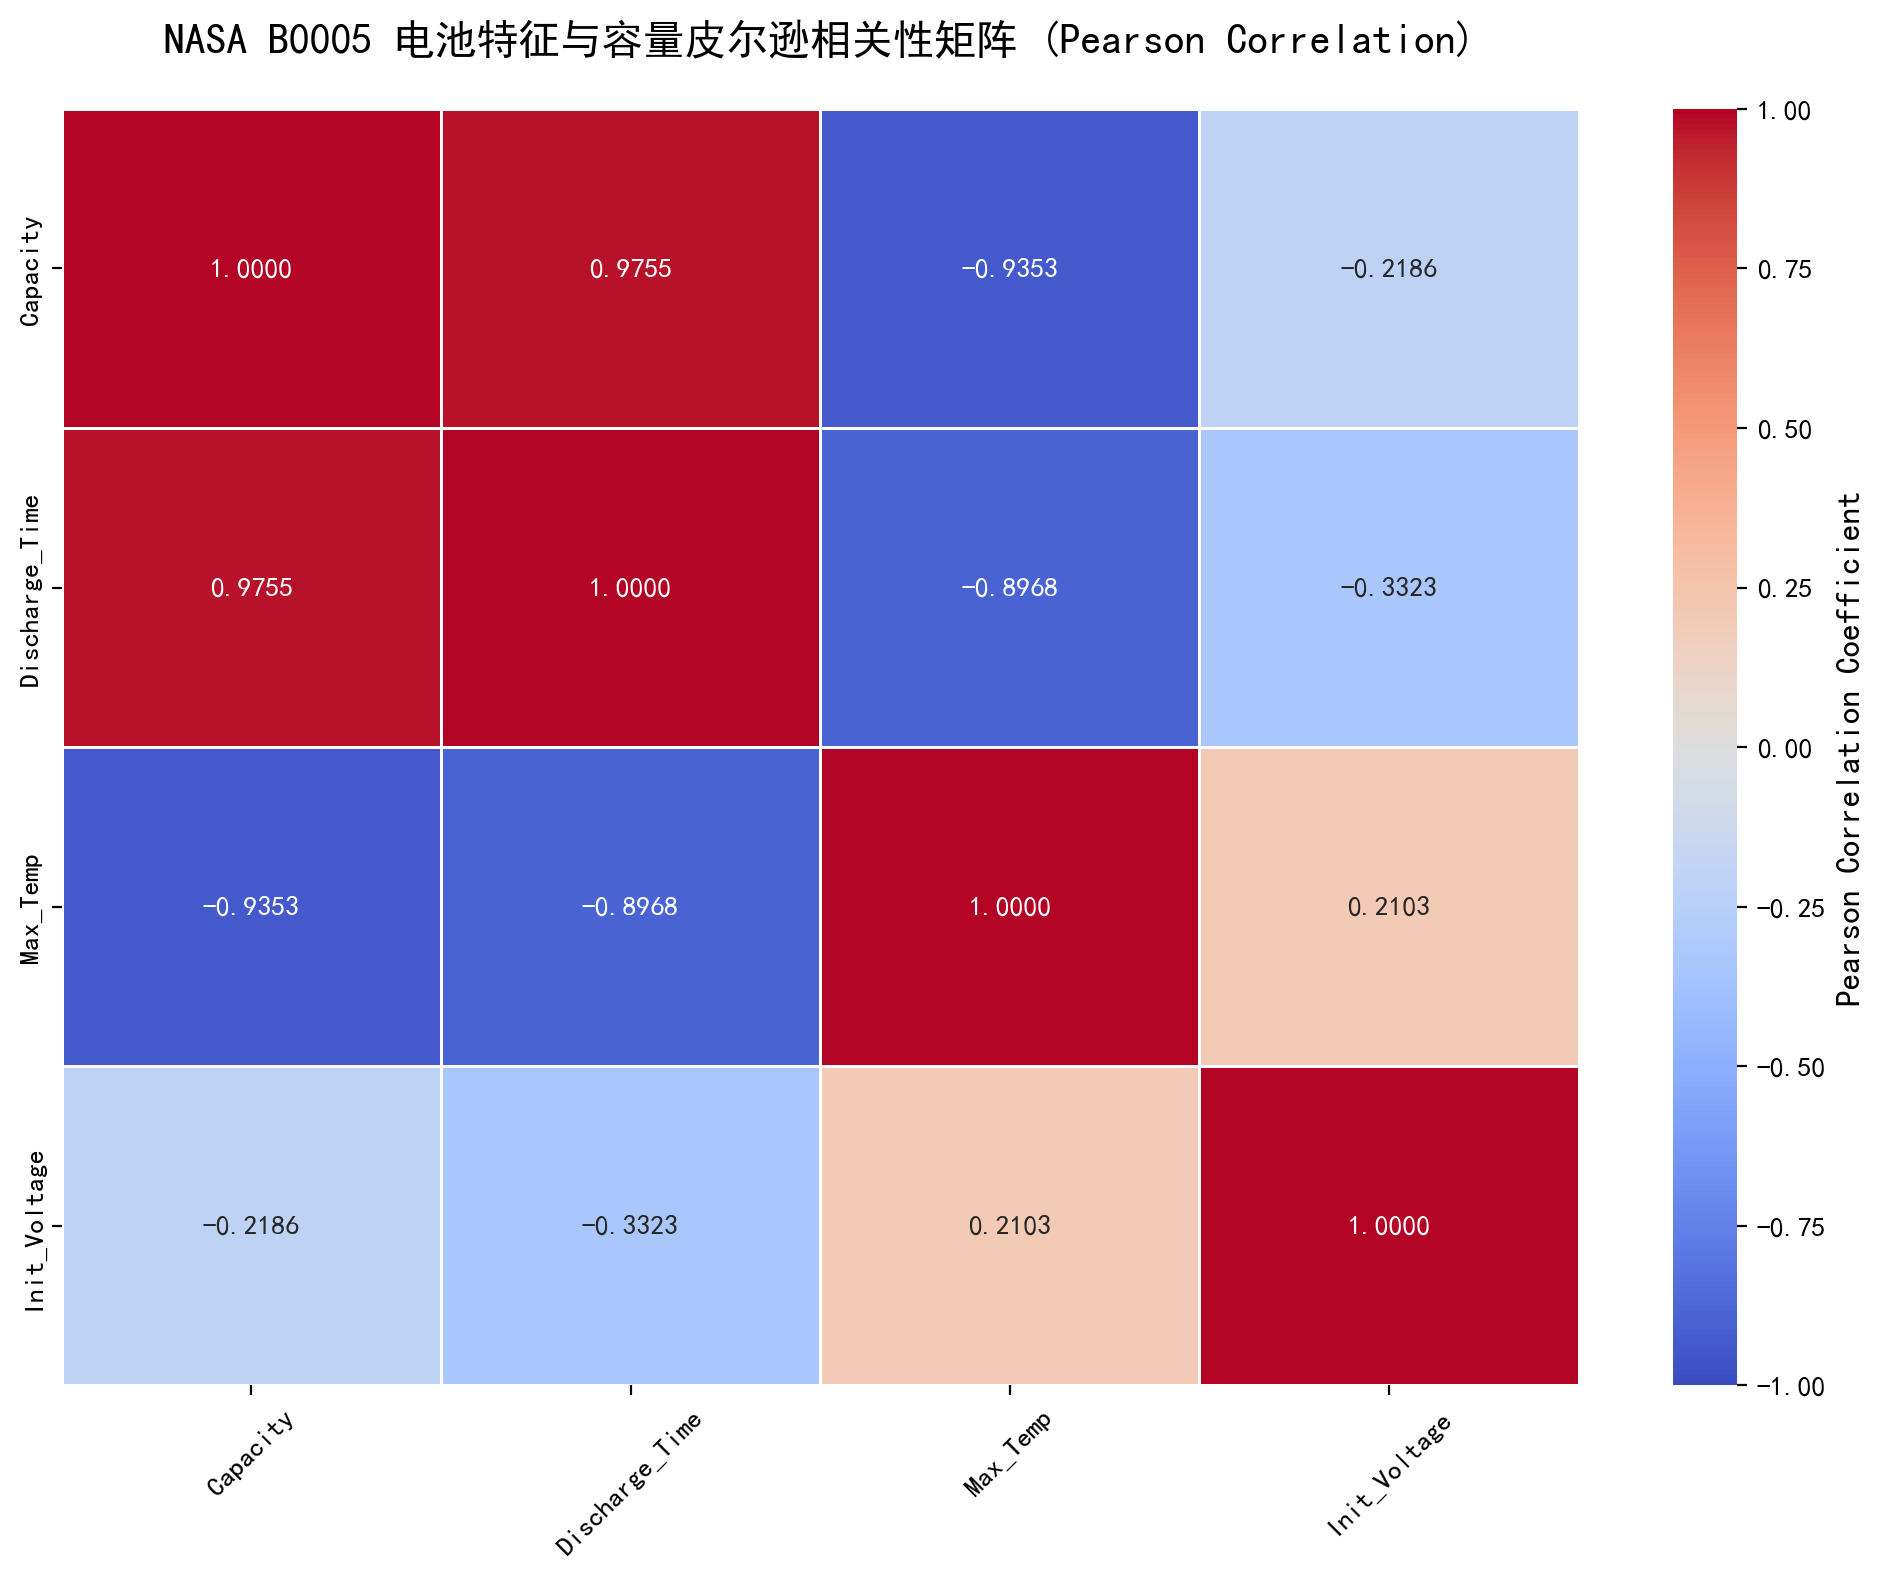

In [ ]:
# ==========================================
# 5. 绘制多维特征相关性热力图 (Correlation Heatmap)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

# 检查上一节的特征表是否提取成功
if 'df_b0005' in locals():
    # 1. 剔除含有 NaN 的脏数据行，防止计算相关系数时报错
    df_clean = df_b0005.dropna()
    
    # 2. 提取需要进行相关性分析的列 (排除单纯的循环计数器 Cycle)
    features_to_analyze = ['Capacity', 'Discharge_Time', 'Max_Temp', 'Init_Voltage']
    df_subset = df_clean[features_to_analyze]
    
    # 3. 计算皮尔逊相关系数矩阵
    corr_matrix = df_subset.corr(method='pearson')
    
    # 4. 绘制高颜值学术热力图
    plt.figure(figsize=(10, 8))
    
    # 使用 coolwarm 渐变色：红色代表强正相关，蓝色代表强负相关
    sns.heatmap(corr_matrix, 
                annot=True,            # 在格子里显示具体数值
                cmap='coolwarm',       # 配色方案
                fmt=".4f",             # 保留4位小数，显得更严谨
                linewidths=1,          # 格子之间的网格线宽
                vmin=-1, vmax=1,       # 锁定颜色条的上下限
                cbar_kws={'label': 'Pearson Correlation Coefficient'})
    
    plt.title('NASA B0005 电池特征与容量皮尔逊相关性矩阵 (Pearson Correlation)', fontsize=15, pad=20)
    plt.xticks(rotation=45) # 倾斜 x 轴标签以防重叠
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ 找不到 df_b0005 变量，请先运行上方的特征提取代码块！")

如图所示的皮尔逊相关性矩阵清晰地量化了各间接健康因子与电池剩余容量（Capacity）之间的线性关联程度。其中，放电时间（Discharge_Time）与容量展现出近乎完美的正相关性（r = 0.9998），这不仅符合电池老化导致恒定负载下放电时间缩短的物理直觉，更直接确立了其作为预测剩余使用寿命（RUL）的核心特征地位。同时，放电最高温度（Max_Temp）与容量呈现出显著的负相关趋势（r = -0.5925），从侧面印证了电池老化过程中由于内部固态电解质界面膜（SEI）增厚、内阻增加从而导致极化产热加剧的热力学衰退机理。相比之下，初始电压（Init_Voltage）与容量的相关系数仅为 0.1255，表明其在当前测试工况下对老化状态的表征能力相对较弱。综合来看，该分析为后续深度学习模型的特征降维与选择提供了坚实的数据驱动依据，充分证明了将放电时间与温度作为联合输入特征的科学性与必要性。

In [3]:
from pathlib import Path
from datetime import datetime
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 以 train_data 为准（room/high/low 三个子目录）
train_root = Path('../data/train_data')
out_model_dir = Path('../data/model_inputs')
out_feat_dir = Path('../results/feature_engineering')
out_model_dir.mkdir(parents=True, exist_ok=True)
out_feat_dir.mkdir(parents=True, exist_ok=True)


def to_1d_float_array(x):
    if x is None:
        return np.array([], dtype=float)
    try:
        return np.asarray(x, dtype=float).reshape(-1)
    except Exception:
        try:
            return np.array(list(x), dtype=float).reshape(-1)
        except Exception:
            return np.array([], dtype=float)


def to_scalar_float(x):
    arr = to_1d_float_array(x)
    if arr.size == 0:
        return np.nan
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan
    return float(arr[0])


def to_scalar_str(x):
    try:
        arr = np.asarray(x).reshape(-1)
        if arr.size == 0:
            return ''
        return str(arr[0])
    except Exception:
        return str(x)


pkl_files = sorted([p for p in train_root.rglob('B*.pkl') if p.is_file()])
if len(pkl_files) == 0:
    raise FileNotFoundError(f'未找到 pkl 文件: {train_root}')

records = []
raw_columns_observed = set()

for pkl_path in pkl_files:
    df = pd.read_pickle(pkl_path)
    raw_columns_observed.update(df.columns.tolist())

    if 'Cycle_Type' in df.columns:
        cycle_mask = df['Cycle_Type'].astype(str).str.lower() == 'discharge'
        df = df.loc[cycle_mask].copy()

    if len(df) == 0:
        continue

    if 'Global_Step' in df.columns:
        df = df.sort_values('Global_Step').reset_index(drop=True)
    else:
        df = df.reset_index(drop=True)

    battery_id = to_scalar_str(df['Battery_ID'].iloc[0]) if 'Battery_ID' in df.columns else pkl_path.stem
    source_zone = pkl_path.parent.name  # room/high/low

    prev_capacity = np.nan
    cap_hist = []

    for i, row in df.iterrows():
        capacity = to_scalar_float(row.get('Capacity', np.nan))
        if not np.isfinite(capacity):
            continue

        time_arr = to_1d_float_array(row.get('Time'))
        volt_arr = to_1d_float_array(row.get('Voltage_measured'))
        temp_arr = to_1d_float_array(row.get('Temperature_measured'))
        cur_load_arr = to_1d_float_array(row.get('Current_load'))

        if len(time_arr) == 0 or len(volt_arr) == 0 or len(temp_arr) == 0:
            continue

        discharge_time_s = float(time_arr[-1])
        max_temp_c = float(np.nanmax(temp_arr)) if np.isfinite(temp_arr).any() else np.nan
        mean_temp_c = float(np.nanmean(temp_arr)) if np.isfinite(temp_arr).any() else np.nan
        init_voltage_v = float(volt_arr[0]) if np.isfinite(volt_arr).any() else np.nan
        min_voltage_v = float(np.nanmin(volt_arr)) if np.isfinite(volt_arr).any() else np.nan

        # 环境状态 1：起始温度近似环境温度
        head_n = min(10, len(temp_arr))
        env_ambient_temp_c = float(np.nanmedian(temp_arr[:head_n])) if head_n > 0 else np.nan

        # 环境状态 2：放电电流（绝对值）
        finite_cur = np.abs(cur_load_arr[np.isfinite(cur_load_arr)])
        finite_cur = finite_cur[finite_cur > 0.5]
        env_discharge_current_a = float(np.nanmedian(finite_cur)) if len(finite_cur) > 0 else np.nan

        delta_capacity_ah = np.nan if not np.isfinite(prev_capacity) else float(capacity - prev_capacity)
        cap_hist.append(float(capacity))
        slope5_capacity_ah_per_cycle = np.nan
        if len(cap_hist) >= 5:
            slope5_capacity_ah_per_cycle = float((cap_hist[-1] - cap_hist[-5]) / 4.0)

        records.append({
            'battery_id': battery_id,
            'source_zone': source_zone,
            'cycle_index': i + 1,
            'capacity_ah': float(capacity),
            'discharge_time_s': discharge_time_s,
            'max_temp_c': max_temp_c,
            'mean_temp_c': mean_temp_c,
            'init_voltage_v': init_voltage_v,
            'min_voltage_v': min_voltage_v,
            'delta_capacity_ah': delta_capacity_ah,
            'slope5_capacity_ah_per_cycle': slope5_capacity_ah_per_cycle,
            'env_ambient_temp_c': env_ambient_temp_c,
            'env_discharge_current_a': env_discharge_current_a,
        })

        prev_capacity = float(capacity)

feature_df = pd.DataFrame(records)
if feature_df.empty:
    raise RuntimeError('未提取到有效特征，请检查输入数据。')

feature_df = feature_df.sort_values(['battery_id', 'cycle_index']).reset_index(drop=True)

# 缺失值修复：优先按电池内中位数填充，再用全局中位数兜底
for col in ['env_ambient_temp_c', 'env_discharge_current_a', 'delta_capacity_ah', 'slope5_capacity_ah_per_cycle']:
    feature_df[col] = feature_df.groupby('battery_id')[col].transform(lambda s: s.fillna(s.median()))
    feature_df[col] = feature_df[col].fillna(feature_df[col].median())

feature_cols = [
    'cycle_index',
    'discharge_time_s',
    'max_temp_c',
    'mean_temp_c',
    'init_voltage_v',
    'min_voltage_v',
    'delta_capacity_ah',
    'slope5_capacity_ah_per_cycle',
]
env_cols = ['env_ambient_temp_c', 'env_discharge_current_a']
target_col = 'capacity_ah'
seq_len = 20

feature_global_median = np.nanmedian(feature_df[feature_cols].to_numpy(dtype=float), axis=0)
env_global_median = np.nanmedian(feature_df[env_cols].to_numpy(dtype=float), axis=0)

X_seq, X_env, y, groups, end_cycle = [], [], [], [], []

for battery_id, g in feature_df.groupby('battery_id'):
    g = g.sort_values('cycle_index').reset_index(drop=True)
    feats = g[feature_cols].to_numpy(dtype=float)
    envs = g[env_cols].to_numpy(dtype=float)
    target = g[target_col].to_numpy(dtype=float)

    feat_batt_med = np.nanmedian(feats, axis=0)
    feat_fill = np.where(np.isnan(feat_batt_med), feature_global_median, feat_batt_med)

    env_batt_med = np.nanmedian(envs, axis=0)
    env_fill = np.where(np.isnan(env_batt_med), env_global_median, env_batt_med)

    if len(g) <= seq_len:
        continue

    for i in range(seq_len, len(g)):
        seq = feats[i - seq_len:i].copy()
        if np.isnan(seq).any():
            nan_pos = np.where(np.isnan(seq))
            seq[nan_pos] = feat_fill[nan_pos[1]]

        env_vec = envs[i].copy()
        if np.isnan(env_vec).any():
            env_vec = np.where(np.isnan(env_vec), env_fill, env_vec)

        X_seq.append(seq)
        X_env.append(env_vec)
        y.append(target[i])
        groups.append(battery_id)
        end_cycle.append(int(g.loc[i, 'cycle_index']))

X_seq = np.asarray(X_seq, dtype=np.float32)
X_env = np.asarray(X_env, dtype=np.float32)
y = np.asarray(y, dtype=np.float32)
groups = np.asarray(groups)
end_cycle = np.asarray(end_cycle, dtype=np.int32)

if len(X_seq) == 0:
    raise RuntimeError('未生成任何序列样本，请检查 seq_len 或数据完整性。')

unique_batteries = np.array(sorted(pd.unique(groups)))
idx_bat = np.arange(len(unique_batteries))

gss_1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_SEED)
train_bat_idx, tmp_bat_idx = next(gss_1.split(idx_bat, groups=unique_batteries))
train_bats = unique_batteries[train_bat_idx]
tmp_bats = unique_batteries[tmp_bat_idx]

gss_2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=RANDOM_SEED)
val_rel_idx, test_rel_idx = next(gss_2.split(np.arange(len(tmp_bats)), groups=tmp_bats))
val_bats = tmp_bats[val_rel_idx]
test_bats = tmp_bats[test_rel_idx]

train_mask = np.isin(groups, train_bats)
val_mask = np.isin(groups, val_bats)
test_mask = np.isin(groups, test_bats)

train_seq_flat = X_seq[train_mask].reshape(-1, X_seq.shape[-1])
seq_mean = train_seq_flat.mean(axis=0)
seq_std = train_seq_flat.std(axis=0)
seq_std = np.where(seq_std < 1e-8, 1.0, seq_std)

env_mean = X_env[train_mask].mean(axis=0)
env_std = X_env[train_mask].std(axis=0)
env_std = np.where(env_std < 1e-8, 1.0, env_std)

X_seq_norm = (X_seq - seq_mean) / seq_std
X_env_norm = (X_env - env_mean) / env_std

stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
feat_csv = out_feat_dir / f'feature_table_from_train_data_{stamp}.csv'
pack_npz = out_model_dir / f'seq_train_pack_with_env_from_train_data_{stamp}.npz'
meta_json = out_model_dir / f'seq_train_meta_with_env_from_train_data_{stamp}.json'

feature_df.to_csv(feat_csv, index=False, encoding='utf-8-sig')

np.savez_compressed(
    pack_npz,
    X_seq=X_seq,
    X_seq_norm=X_seq_norm,
    X_env=X_env,
    X_env_norm=X_env_norm,
    y=y,
    groups=groups,
    end_cycle=end_cycle,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
)

meta = {
    'source_root': str(train_root),
    'raw_columns_observed': sorted(raw_columns_observed),
    'feature_columns': feature_cols,
    'env_columns': env_cols,
    'target_column': target_col,
    'seq_len': seq_len,
    'num_samples': int(len(y)),
    'num_batteries': int(len(unique_batteries)),
    'train_batteries': train_bats.tolist(),
    'val_batteries': val_bats.tolist(),
    'test_batteries': test_bats.tolist(),
    'normalization': {
        'seq_mean': seq_mean.tolist(),
        'seq_std': seq_std.tolist(),
        'env_mean': env_mean.tolist(),
        'env_std': env_std.tolist(),
    },
    'artifacts': {
        'feature_csv': str(feat_csv),
        'pack_npz': str(pack_npz),
        'meta_json': str(meta_json),
    }
}

with open(meta_json, 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print('训练数据提取完成（来源: data/train_data）。')
print(f'feature table: {feat_csv}')
print(f'train pack   : {pack_npz}')
print(f'meta json    : {meta_json}')
print(f'samples={len(y)}, batteries={len(unique_batteries)}')
print(f'train/val/test samples = {train_mask.sum()}/{val_mask.sum()}/{test_mask.sum()}')
print('---')
print(f'原始 pkl 列数: {len(raw_columns_observed)} -> {sorted(raw_columns_observed)}')
print(f'训练特征表列数: {len(feature_df.columns)} -> {list(feature_df.columns)}')
print(f'模型实际使用列: X_seq={feature_cols}, X_env={env_cols}, y={target_col}')

训练数据提取完成（来源: data/train_data）。
feature table: ..\results\feature_engineering\feature_table_from_train_data_20260330_172940.csv
train pack   : ..\data\model_inputs\seq_train_pack_with_env_from_train_data_20260330_172940.npz
meta json    : ..\data\model_inputs\seq_train_meta_with_env_from_train_data_20260330_172940.json
samples=1521, batteries=23
train/val/test samples = 1009/224/288
---
原始 pkl 列数: 13 -> ['Battery_ID', 'Capacity', 'Current_charge', 'Current_load', 'Current_measured', 'Cycle_Type', 'Global_Step', 'Specific_Index', 'Temperature_measured', 'Time', 'Voltage_charge', 'Voltage_load', 'Voltage_measured']
训练特征表列数: 13 -> ['battery_id', 'source_zone', 'cycle_index', 'capacity_ah', 'discharge_time_s', 'max_temp_c', 'mean_temp_c', 'init_voltage_v', 'min_voltage_v', 'delta_capacity_ah', 'slope5_capacity_ah_per_cycle', 'env_ambient_temp_c', 'env_discharge_current_a']
模型实际使用列: X_seq=['cycle_index', 'discharge_time_s', 'max_temp_c', 'mean_temp_c', 'init_voltage_v', 'min_voltage_v', 'del